# Supply Chain & Logistics Data Analysis

Analysis of delivery performance, sales, profitability, shipping modes,
markets, customer segments and product categories using Python and Pandas.


In [91]:
import pandas as pd
import matplotlib.pyplot as plt

In [90]:
df = pd.read_csv(
    "DataCoSupplyChainDataset.csv.csv",
    encoding="latin-1"
)

print(df.shape)

(180519, 53)


In [6]:
from google.colab import files

uploaded = files.upload()

Saving DataCoSupplyChainDataset.csv.csv to DataCoSupplyChainDataset.csv.csv


In [11]:
import pandas as pd

df = pd.read_csv(
    "DataCoSupplyChainDataset.csv.csv",
    encoding="latin-1"
)

print(df.shape)

(180519, 53)


In [12]:
df.columns.tolist()

['Type',
 'Days for shipping (real)',
 'Days for shipment (scheduled)',
 'Benefit per order',
 'Sales per customer',
 'Delivery Status',
 'Late_delivery_risk',
 'Category Id',
 'Category Name',
 'Customer City',
 'Customer Country',
 'Customer Email',
 'Customer Fname',
 'Customer Id',
 'Customer Lname',
 'Customer Password',
 'Customer Segment',
 'Customer State',
 'Customer Street',
 'Customer Zipcode',
 'Department Id',
 'Department Name',
 'Latitude',
 'Longitude',
 'Market',
 'Order City',
 'Order Country',
 'Order Customer Id',
 'order date (DateOrders)',
 'Order Id',
 'Order Item Cardprod Id',
 'Order Item Discount',
 'Order Item Discount Rate',
 'Order Item Id',
 'Order Item Product Price',
 'Order Item Profit Ratio',
 'Order Item Quantity',
 'Sales',
 'Order Item Total',
 'Order Profit Per Order',
 'Order Region',
 'Order State',
 'Order Status',
 'Order Zipcode',
 'Product Card Id',
 'Product Category Id',
 'Product Description',
 'Product Image',
 'Product Name',
 'Product P

In [14]:
df['Delivery delay'] = (
    df['Days for shipping (real)']
    - df['Days for shipment (scheduled)']
)

In [19]:
delay_summary = pd.Series({
    'Early': (df['Delivery delay'] < 0).sum(),
    'On time': (df['Delivery delay'] == 0).sum(),
    'Delayed': (df['Delivery delay'] > 0).sum()
})

delay_percentage = (delay_summary / len(df) * 100).round(2)

delay_percentage

,0
Early,24.02
On time,18.70
Delayed,57.28


In [20]:
df['Delivery Status'].value_counts()

,count
Delivery Status,
Late delivery,98977
Advance shipping,41592
Shipping on time,32196
Shipping canceled,7754


In [22]:
df['Shipping Mode'].value_counts()

,count
Shipping Mode,
Standard Class,107752
Second Class,35216
First Class,27814
Same Day,9737


In [23]:
shipping_status = pd.crosstab(
    df['Shipping Mode'],
    df['Delivery Status'],
    normalize='index'
).mul(100).round(2)

shipping_status

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Shipping Mode,,,,
First Class,0.0,95.32,4.68,0.00
Same Day,0.0,45.74,4.56,49.70
Second Class,0.0,76.63,4.00,19.36
Standard Class,38.6,38.07,4.27,19.06


In [24]:
market_status = pd.crosstab(
    df['Market'],
    df['Delivery Status'],
    normalize='index'
).mul(100).round(2)

market_status

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Market,,,,
Africa,22.77,54.59,3.96,18.68
Europe,23.09,55.21,4.30,17.40
LATAM,23.33,54.36,4.43,17.88
Pacific Asia,22.96,55.05,4.06,17.94
USCA,22.60,54.80,4.54,18.05


In [26]:
segment_status = pd.crosstab(
    df['Customer Segment'],
    df['Delivery Status'],
    normalize='index'
).mul(100).round(2)

segment_status

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Customer Segment,,,,
Consumer,22.87,54.81,4.37,17.95
Corporate,23.46,54.72,4.13,17.69
Home Office,22.80,55.07,4.37,17.76


In [28]:
category_status = pd.crosstab(
    df['Category Name'],
    df['Delivery Status'],
    normalize='index'
).mul(100).round(2)

category_status

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Category Name,,,,
Accessories,22.81,56.97,4.66,15.56
As Seen on TV!,22.06,57.35,2.94,17.65
Baby,23.67,52.66,4.35,19.32
Baseball & Softball,22.31,55.22,3.96,18.51
Basketball,32.84,55.22,4.48,7.46
Books,21.48,56.54,3.46,18.52
Boxing & MMA,19.86,56.26,4.96,18.91
CDs,24.72,52.03,2.95,20.30
Cameras,21.28,58.11,5.07,15.54


In [30]:
department_status = pd.crosstab(
    df['Department Name'],
    df['Delivery Status'],
    normalize='index'
).mul(100).round(2)

department_status

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Department Name,,,,
Apparel,22.82,54.75,4.31,18.12
Book Shop,21.48,56.54,3.46,18.52
Discs Shop,23.15,54.44,4.10,18.31
Fan Shop,23.04,54.77,4.23,17.96
Fitness,23.07,55.55,4.24,17.14
Footwear,23.19,54.73,4.36,17.72
Golf,23.20,54.78,4.37,17.65
Health and Beauty,22.93,55.80,4.42,16.85
Outdoors,23.63,55.49,4.33,16.55


In [32]:
late_orders_department = (
    df[df['Delivery Status'] == 'Late delivery']
    .groupby('Department Name')
    .size()
    .sort_values(ascending=False)
)

late_orders_department

,0
Department Name,
Fan Shop,36623
Apparel,26825
Golf,18198
Footwear,7949
Outdoors,5375
Fitness,1377
Discs Shop,1103
Technology,806
Pet Shop,290


In [33]:
df['order date (DateOrders)'] = pd.to_datetime(
    df['order date (DateOrders)']
)

print(df['order date (DateOrders)'].min())
print(df['order date (DateOrders)'].max())

2015-01-01 00:00:00
2018-01-31 23:38:00


In [34]:
df['Month'] = df['order date (DateOrders)'].dt.to_period('M')

monthly_delivery = (
    pd.crosstab(
        df['Month'],
        df['Delivery Status'],
        normalize='index'
    )
    .mul(100)
    .round(2)
)

monthly_delivery

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Month,,,,
2015-01,23.37,54.11,3.91,18.60
2015-02,23.13,54.85,5.12,16.90
2015-03,23.07,54.76,4.38,17.79
2015-04,23.94,53.84,4.12,18.10
2015-05,22.98,55.09,5.04,16.89
2015-06,24.02,54.11,4.40,17.47
2015-07,23.82,55.46,3.30,17.42
2015-08,22.76,55.68,4.70,16.86
2015-09,22.53,56.69,4.16,16.61


In [35]:
monthly_orders = df['Month'].value_counts().sort_index()

monthly_orders

,count
Month,
2015-01,5322
2015-02,4729
2015-03,5362
2015-04,5126
2015-05,5357
2015-06,5134
2015-07,5299
2015-08,5273
2015-09,5140


In [36]:
monthly_late_rate = (
    df.groupby('Month')['Delivery Status']
    .apply(lambda x: (x == 'Late delivery').mean() * 100)
)

monthly_late_rate

,Delivery Status
Month,
2015-01,54.114994
2015-02,54.853034
2015-03,54.755688
2015-04,53.843153
2015-05,55.086802
2015-06,54.109856
2015-07,55.463295
2015-08,55.679879
2015-09,56.692607


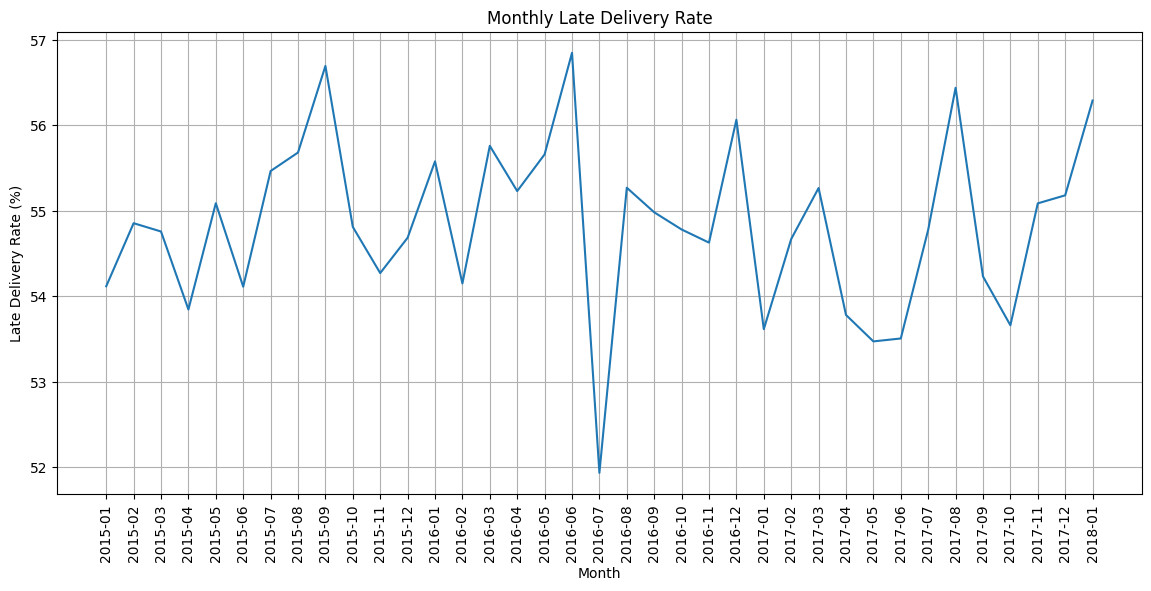

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_late_rate.index.astype(str),
    monthly_late_rate.values
)

plt.xticks(rotation=90)
plt.xlabel('Month')
plt.ylabel('Late Delivery Rate (%)')
plt.title('Monthly Late Delivery Rate')
plt.grid(True)

plt.show()

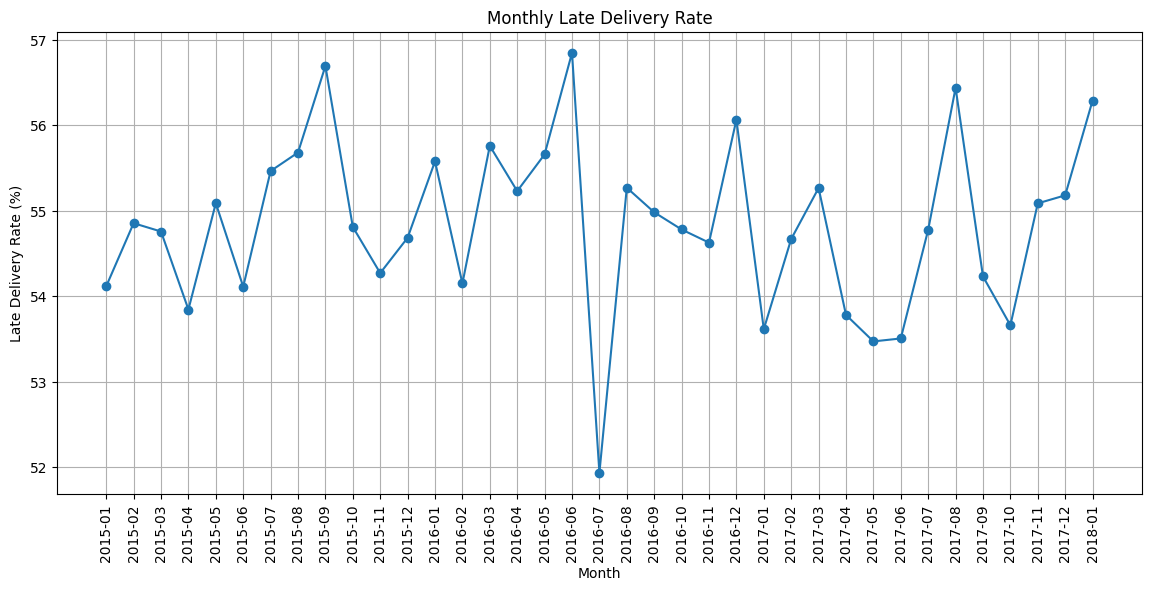

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_late_rate.index.astype(str),
    monthly_late_rate.values,
    marker='o'
)

plt.xticks(rotation=90)
plt.xlabel('Month')
plt.ylabel('Late Delivery Rate (%)')
plt.title('Monthly Late Delivery Rate')
plt.grid(True)

plt.show()

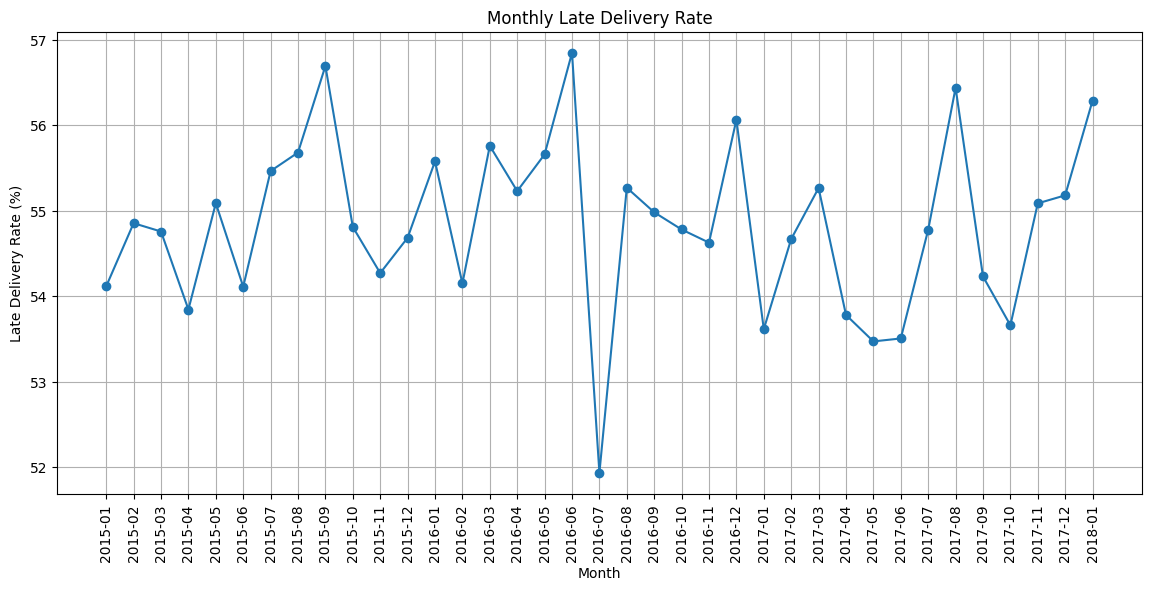

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_late_rate.index.astype(str),
    monthly_late_rate.values,
    marker='o'
)

plt.xlabel('Month')
plt.ylabel('Late Delivery Rate (%)')
plt.title('Monthly Late Delivery Rate')

plt.xticks(rotation=90)
plt.grid(True)

plt.show()

In [40]:
market_financials = (
    df.groupby('Market')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Order Profit Per Order', 'sum'),
        Orders=('Order Id', 'count')
    )
    .sort_values('Total_Sales', ascending=False)
)

market_financials

,Total_Sales,Total_Profit,Orders
Market,,,
Europe,1.087240e+07,1.169443e+06,50252
LATAM,1.027761e+07,1.123322e+06,51594
Pacific Asia,8.273744e+06,8.577534e+05,41260
USCA,5.066529e+06,5.643138e+05,25799
Africa,2.294453e+06,2.520712e+05,11614


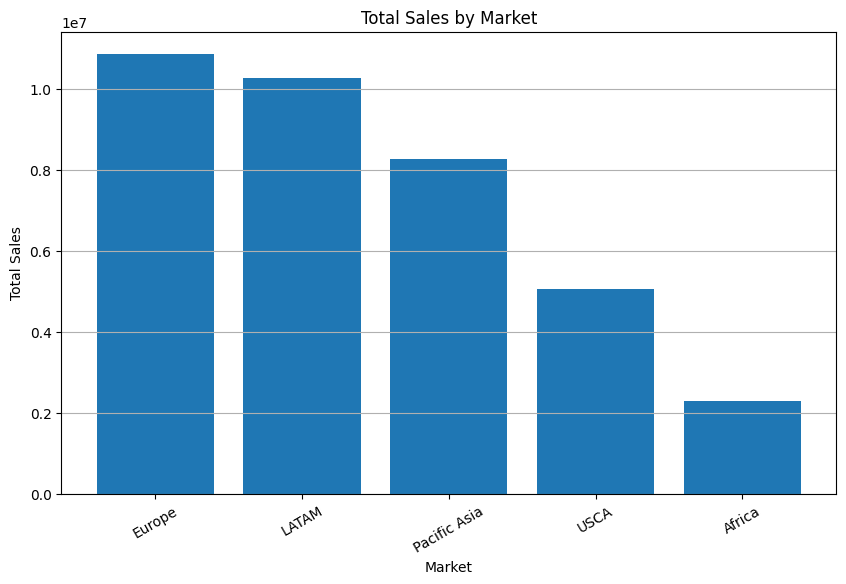

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    market_financials.index,
    market_financials['Total_Sales']
)

plt.xlabel('Market')
plt.ylabel('Total Sales')
plt.title('Total Sales by Market')

plt.xticks(rotation=30)
plt.grid(axis='y')

plt.show()

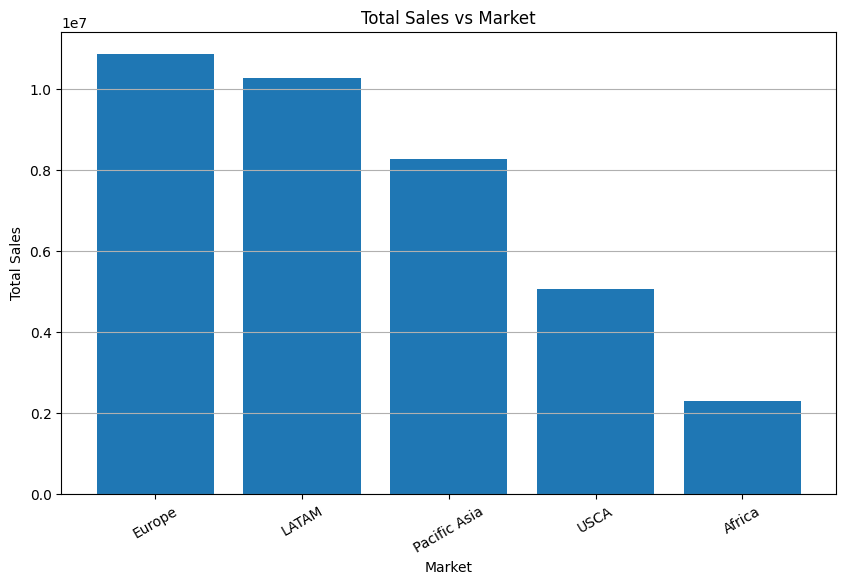

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    market_financials.index,
    market_financials['Total_Sales']
)

plt.xlabel('Market')
plt.ylabel('Total Sales')
plt.title('Total Sales vs Market')

plt.xticks(rotation=30)
plt.grid(axis='y')

plt.show()

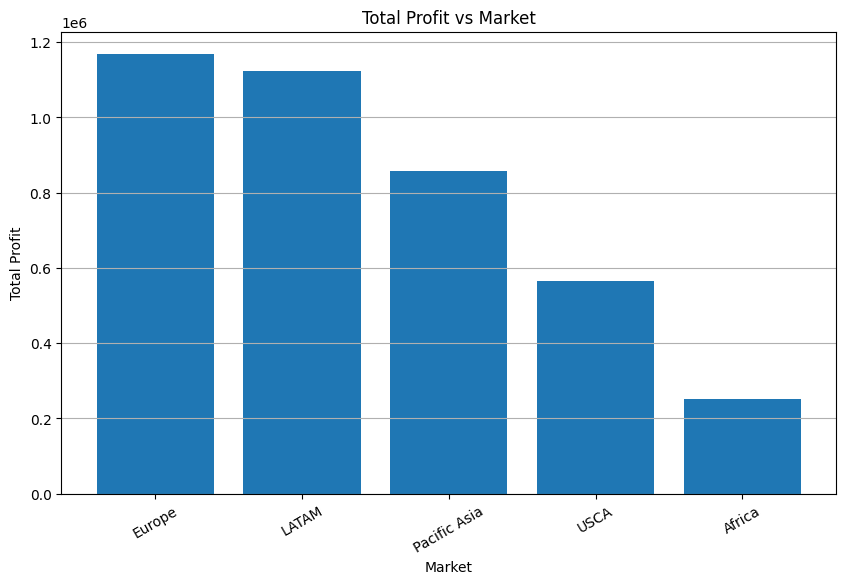

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    market_financials.index,
    market_financials['Total_Profit']
)

plt.xlabel('Market')
plt.ylabel('Total Profit')
plt.title('Total Profit vs Market')

plt.xticks(rotation=30)
plt.grid(axis='y')

plt.show()

In [44]:
market_financials['Profit_per_Order'] = (
    market_financials['Total_Profit']
    / market_financials['Orders']
)

market_financials

,Total_Sales,Total_Profit,Orders,Profit_per_Order
Market,,,,
Europe,1.087240e+07,1.169443e+06,50252,23.271571
LATAM,1.027761e+07,1.123322e+06,51594,21.772330
Pacific Asia,8.273744e+06,8.577534e+05,41260,20.788983
USCA,5.066529e+06,5.643138e+05,25799,21.873475
Africa,2.294453e+06,2.520712e+05,11614,21.704080


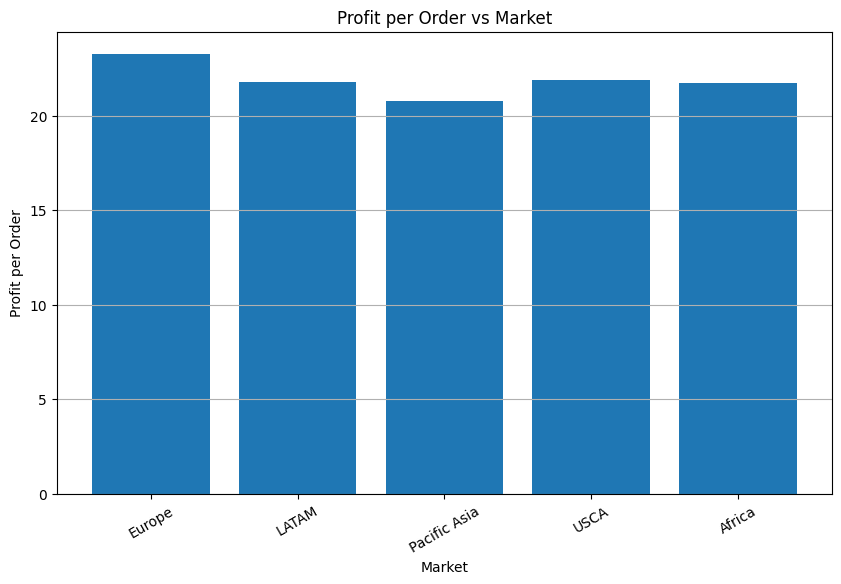

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    market_financials.index,
    market_financials['Profit_per_Order']
)

plt.xlabel('Market')
plt.ylabel('Profit per Order')
plt.title('Profit per Order vs Market')

plt.xticks(rotation=30)
plt.grid(axis='y')

plt.show()

In [46]:
product_sales = (
    df.groupby('Product Name')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Order Profit Per Order', 'sum'),
        Orders=('Order Id', 'count')
    )
    .sort_values('Total_Sales', ascending=False)
)

product_sales.head(10)

,Total_Sales,Total_Profit,Orders
Product Name,,,
Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06,756220.767190,17325
Perfect Fitness Perfect Rip Deck,4.421143e+06,493828.299782,24515
Diamondback Women's Serene Classic Comfort Bi,4.118426e+06,427455.568106,13729
Nike Men's Free 5.0+ Running Shoe,3.667633e+06,379915.818503,12169
Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06,350421.029567,21035
Pelican Sunstream 100 Kayak,3.099845e+06,324076.370020,15500
Nike Men's CJ Elite 2 TD Football Cleat,2.891758e+06,311902.820214,22246
O'Brien Men's Neoprene Life Vest,2.888994e+06,318451.430554,19298
Under Armour Girls' Toddler Spine Surge Runni,1.269083e+06,126278.510299,10617


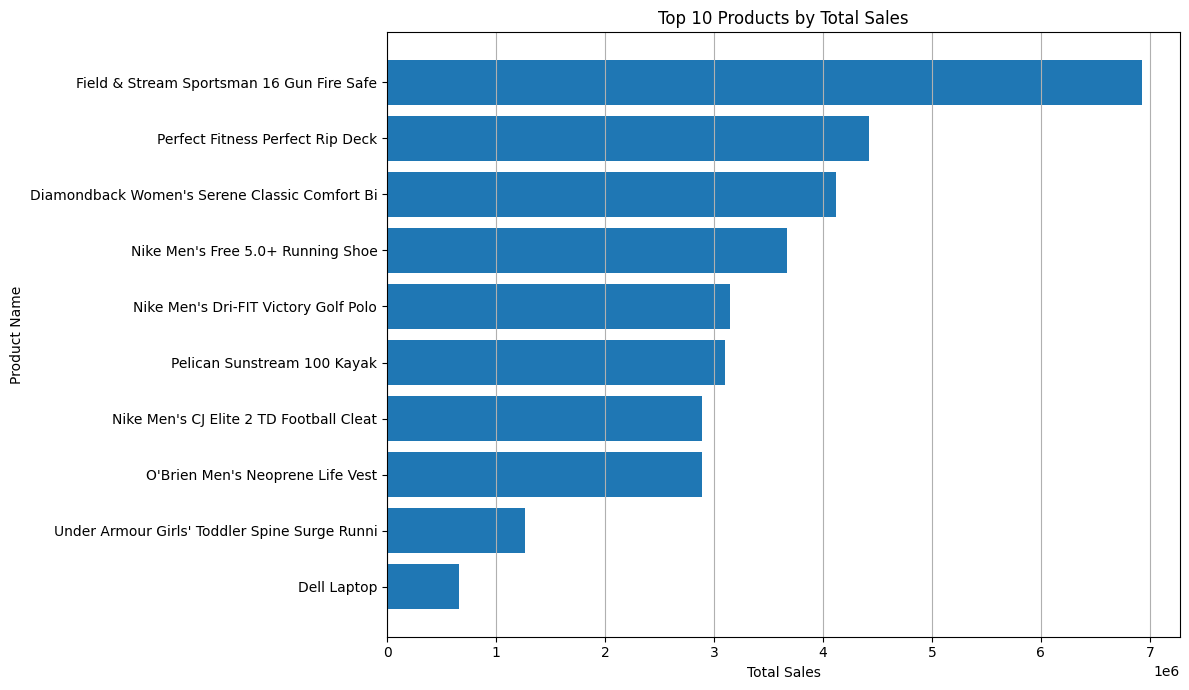

In [47]:
top_products = product_sales.head(10).sort_values('Total_Sales')

plt.figure(figsize=(12, 7))

plt.barh(
    top_products.index,
    top_products['Total_Sales']
)

plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.title('Top 10 Products by Total Sales')

plt.grid(axis='x')
plt.tight_layout()

plt.show()

In [48]:
top_profit_products = (
    product_sales
    .sort_values('Total_Profit', ascending=False)
    .head(10)
)

top_profit_products


,Total_Sales,Total_Profit,Orders
Product Name,,,
Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06,756220.767190,17325
Perfect Fitness Perfect Rip Deck,4.421143e+06,493828.299782,24515
Diamondback Women's Serene Classic Comfort Bi,4.118426e+06,427455.568106,13729
Nike Men's Free 5.0+ Running Shoe,3.667633e+06,379915.818503,12169
Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06,350421.029567,21035
Pelican Sunstream 100 Kayak,3.099845e+06,324076.370020,15500
O'Brien Men's Neoprene Life Vest,2.888994e+06,318451.430554,19298
Nike Men's CJ Elite 2 TD Football Cleat,2.891758e+06,311902.820214,22246
Under Armour Girls' Toddler Spine Surge Runni,1.269083e+06,126278.510299,10617


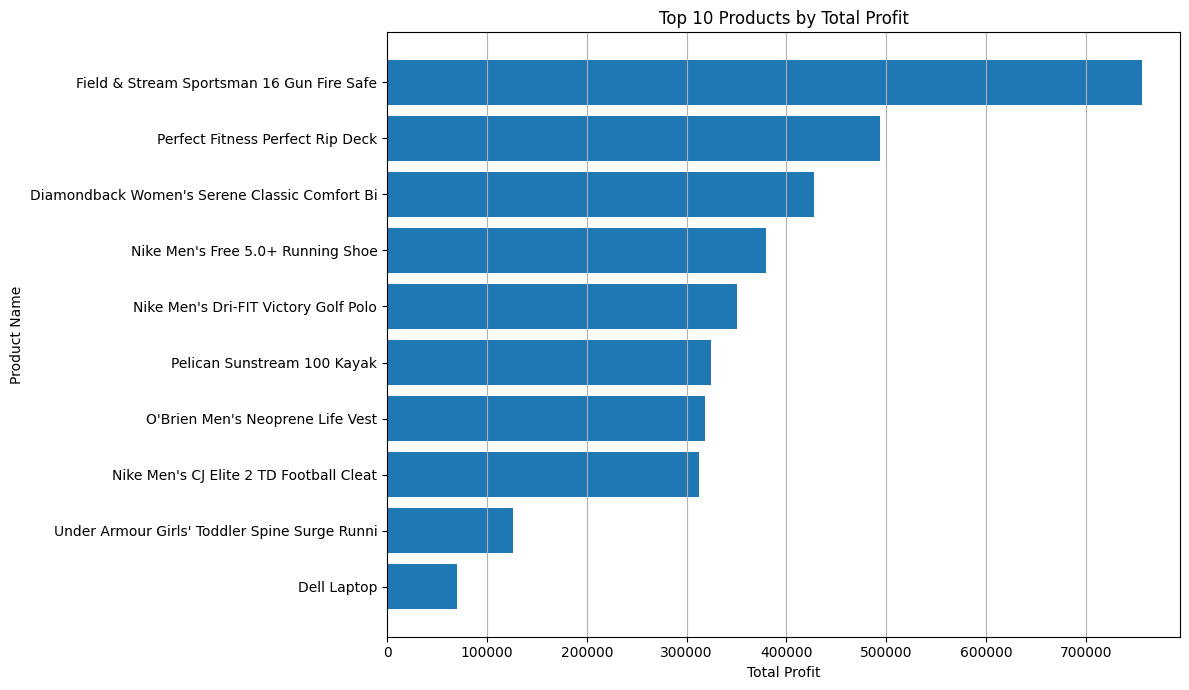

In [49]:
top_profit_products = (
    product_sales
    .sort_values('Total_Profit', ascending=False)
    .head(10)
    .sort_values('Total_Profit')
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_profit_products.index,
    top_profit_products['Total_Profit']
)

plt.xlabel('Total Profit')
plt.ylabel('Product Name')
plt.title('Top 10 Products by Total Profit')

plt.grid(axis='x')
plt.tight_layout()

plt.show()

In [50]:
category_financials = (
    df.groupby('Category Name')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Order Profit Per Order', 'sum'),
        Orders=('Order Id', 'count')
    )
    .sort_values('Total_Sales', ascending=False)
)

category_financials.head(10)

,Total_Sales,Total_Profit,Orders
Category Name,,,
Fishing,6.929654e+06,756220.767190,17325
Cleats,4.431943e+06,494636.919791,24551
Camping & Hiking,4.118426e+06,427455.568106,13729
Cardio Equipment,3.694843e+06,383011.098485,12487
Women's Apparel,3.147800e+06,350421.029567,21035
Water Sports,3.113845e+06,325146.960038,15540
Men's Footwear,2.891758e+06,311902.820214,22246
Indoor/Outdoor Games,2.888994e+06,318451.430554,19298
Shop By Sport,1.309522e+06,129813.960315,10984


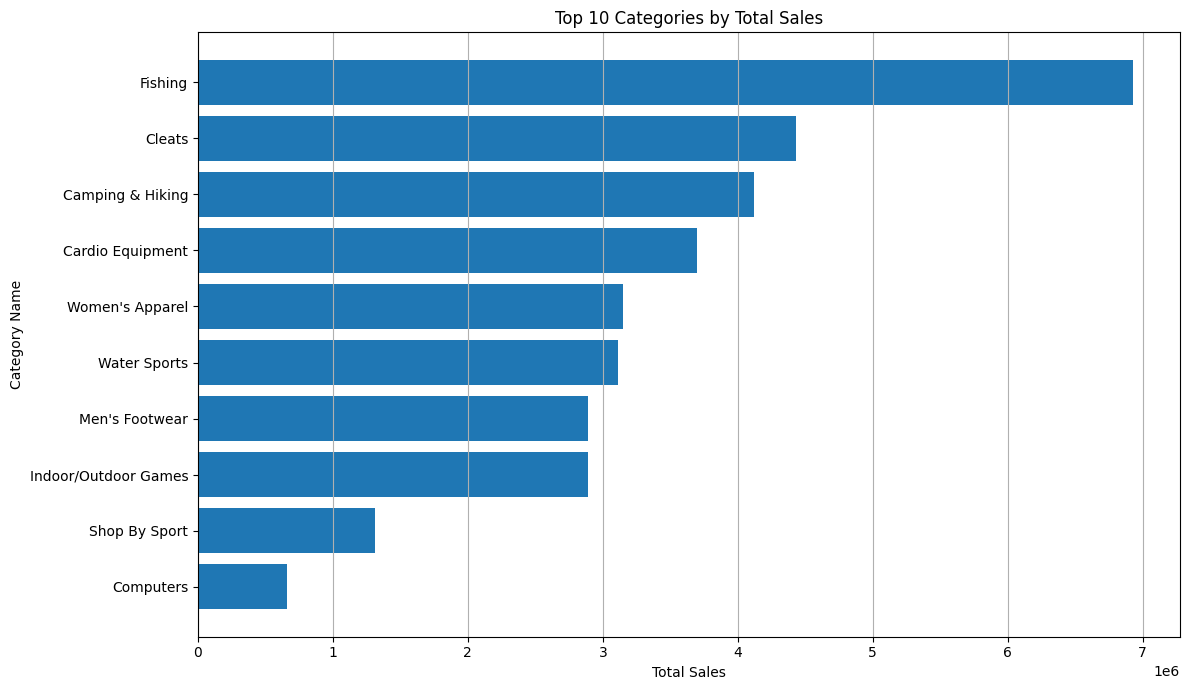

In [51]:
top_categories = (
    category_financials
    .head(10)
    .sort_values('Total_Sales')
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_categories.index,
    top_categories['Total_Sales']
)

plt.xlabel('Total Sales')
plt.ylabel('Category Name')
plt.title('Top 10 Categories by Total Sales')

plt.grid(axis='x')
plt.tight_layout()

plt.show()

In [52]:
top_profit_categories = (
    category_financials
    .sort_values('Total_Profit', ascending=False)
    .head(10)
)

top_profit_categories

,Total_Sales,Total_Profit,Orders
Category Name,,,
Fishing,6.929654e+06,756220.767190,17325
Cleats,4.431943e+06,494636.919791,24551
Camping & Hiking,4.118426e+06,427455.568106,13729
Cardio Equipment,3.694843e+06,383011.098485,12487
Women's Apparel,3.147800e+06,350421.029567,21035
Water Sports,3.113845e+06,325146.960038,15540
Indoor/Outdoor Games,2.888994e+06,318451.430554,19298
Men's Footwear,2.891758e+06,311902.820214,22246
Shop By Sport,1.309522e+06,129813.960315,10984


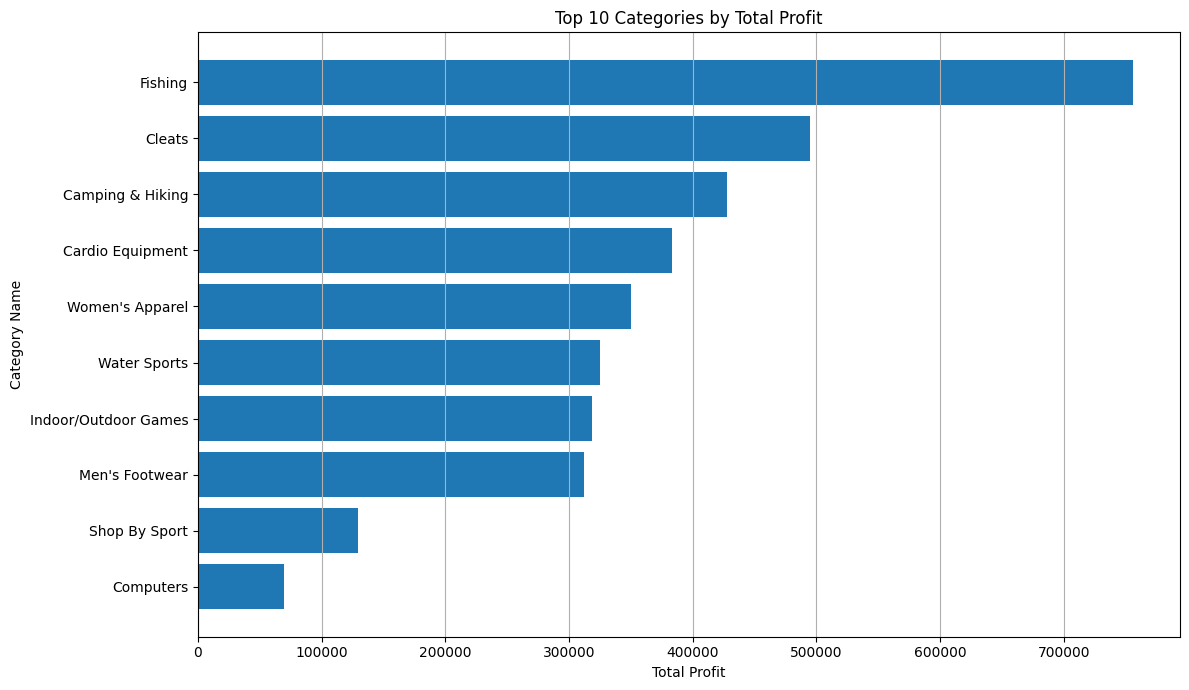

In [53]:
top_profit_categories = (
    category_financials
    .sort_values('Total_Profit', ascending=False)
    .head(10)
    .sort_values('Total_Profit')
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_profit_categories.index,
    top_profit_categories['Total_Profit']
)

plt.xlabel('Total Profit')
plt.ylabel('Category Name')
plt.title('Top 10 Categories by Total Profit')

plt.grid(axis='x')
plt.tight_layout()

plt.show()

In [54]:
category_financials['Profit_per_Order'] = (
    category_financials['Total_Profit']
    / category_financials['Orders']
)

category_financials.sort_values(
    'Profit_per_Order',
    ascending=False
).head(10)

,Total_Sales,Total_Profit,Orders,Profit_per_Order
Category Name,,,,
Computers,6.630000e+05,69656.810171,442,157.594593
Garden,2.577687e+05,33443.010106,484,69.097128
Crafts,2.233563e+05,25531.170060,484,52.750351
Cameras,2.676077e+05,30289.799946,592,51.165203
Fishing,6.929654e+06,756220.767190,17325,43.649106
Children's Clothing,2.328292e+05,27178.099597,652,41.684202
Sporting Goods,1.170068e+05,12518.610119,357,35.066135
Music,1.131221e+05,14436.319923,434,33.263410
Camping & Hiking,4.118426e+06,427455.568106,13729,31.135230


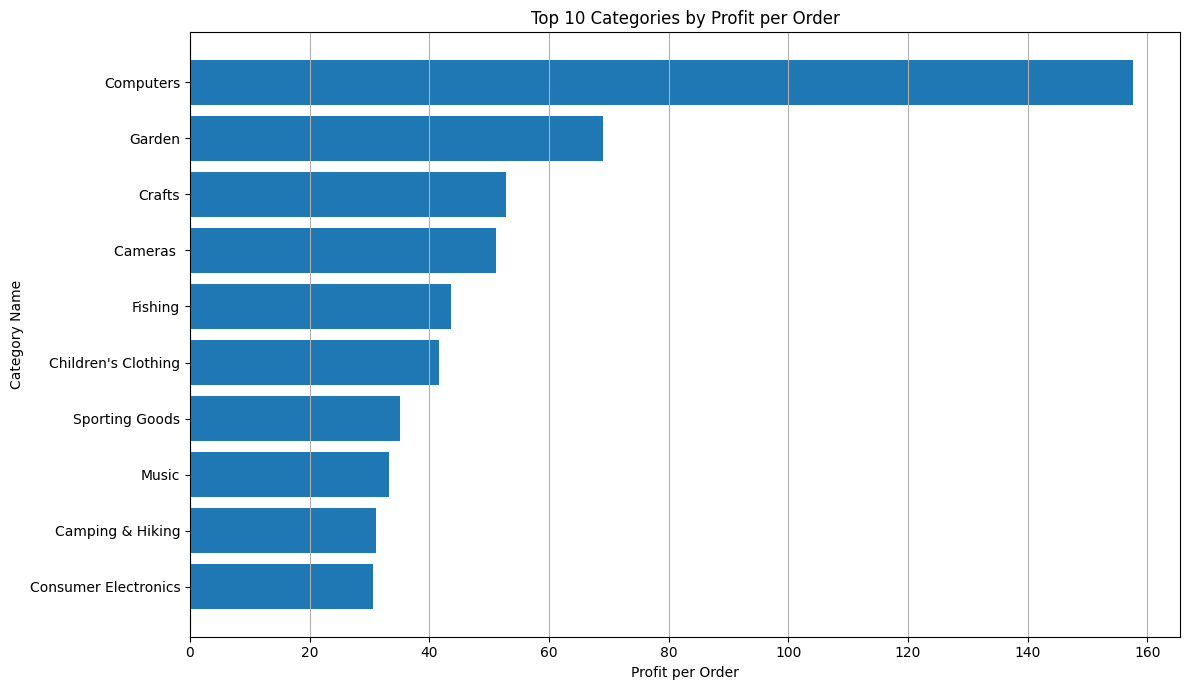

In [55]:
top_profit_per_order = (
    category_financials
    .sort_values('Profit_per_Order', ascending=False)
    .head(10)
    .sort_values('Profit_per_Order')
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_profit_per_order.index,
    top_profit_per_order['Profit_per_Order']
)

plt.xlabel('Profit per Order')
plt.ylabel('Category Name')
plt.title('Top 10 Categories by Profit per Order')

plt.grid(axis='x')
plt.tight_layout()

plt.show()

In [60]:
shipping_financials = (
    df.groupby('Shipping Mode')
    .agg(
        Total_Sales=('Sales', 'sum'),
        Total_Profit=('Order Profit Per Order', 'sum'),
        Orders=('Order Id', 'count')
    )
    .sort_values('Total_Sales', ascending=False)
)

shipping_financials

,Total_Sales,Total_Profit,Orders
Shipping Mode,,,
Standard Class,2.202239e+07,2.370454e+06,107752
Second Class,7.145445e+06,7.503082e+05,35216
First Class,5.674370e+06,6.431219e+05,27814
Same Day,1.942529e+06,2.030184e+05,9737


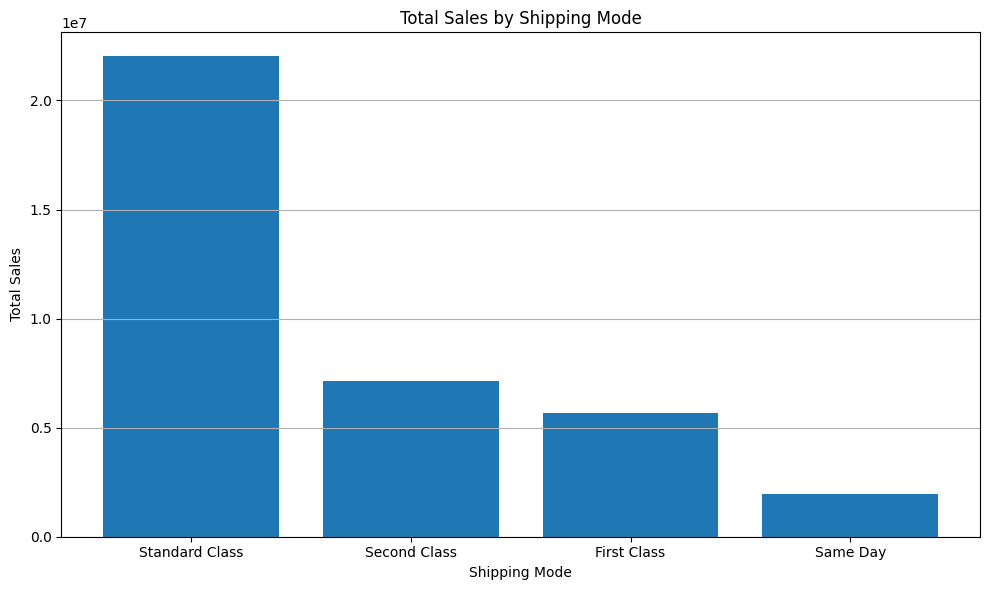

In [61]:
plt.figure(figsize=(10, 6))

plt.bar(
    shipping_financials.index,
    shipping_financials['Total_Sales']
)

plt.xlabel('Shipping Mode')
plt.ylabel('Total Sales')
plt.title('Total Sales by Shipping Mode')

plt.grid(axis='y')
plt.tight_layout()

plt.show()

In [62]:
shipping_financials['Profit_per_Order'] = (
    shipping_financials['Total_Profit']
    / shipping_financials['Orders']
)

shipping_financials

,Total_Sales,Total_Profit,Orders,Profit_per_Order
Shipping Mode,,,,
Standard Class,2.202239e+07,2.370454e+06,107752,21.999169
Second Class,7.145445e+06,7.503082e+05,35216,21.305889
First Class,5.674370e+06,6.431219e+05,27814,23.122238
Same Day,1.942529e+06,2.030184e+05,9737,20.850203


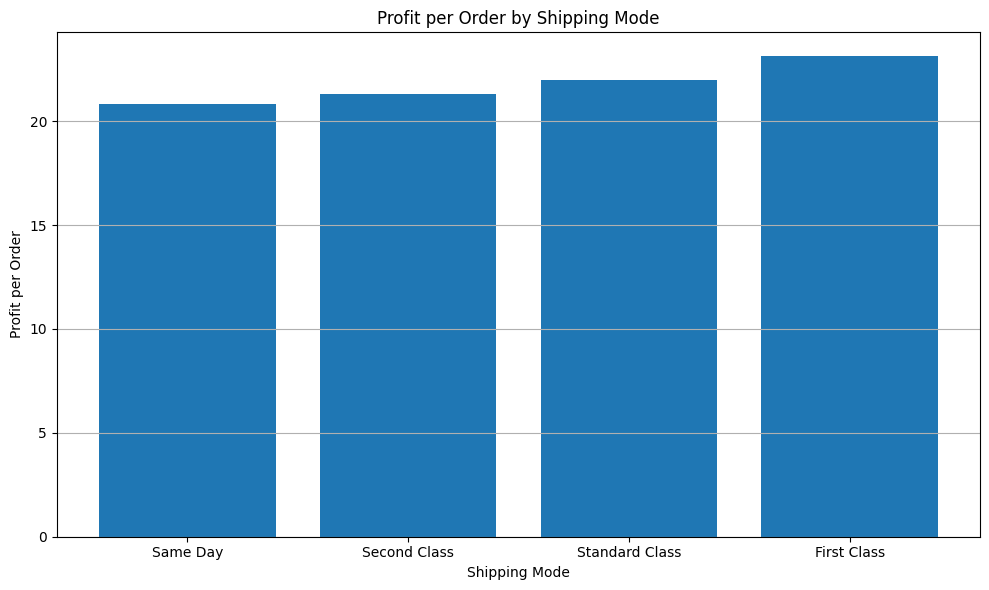

In [63]:
shipping_profit_order = shipping_financials.sort_values(
    'Profit_per_Order'
)

plt.figure(figsize=(10, 6))

plt.bar(
    shipping_profit_order.index,
    shipping_profit_order['Profit_per_Order']
)

plt.xlabel('Shipping Mode')
plt.ylabel('Profit per Order')
plt.title('Profit per Order by Shipping Mode')

plt.grid(axis='y')
plt.tight_layout()

plt.show()

In [78]:
monthly_sales = (
    df.groupby('Month')['Sales']
    .sum()
)

monthly_sales.head()

,Sales
Month,
2015-01,1.051590e+06
2015-02,9.270099e+05
2015-03,1.051254e+06
2015-04,1.014463e+06
2015-05,1.050478e+06


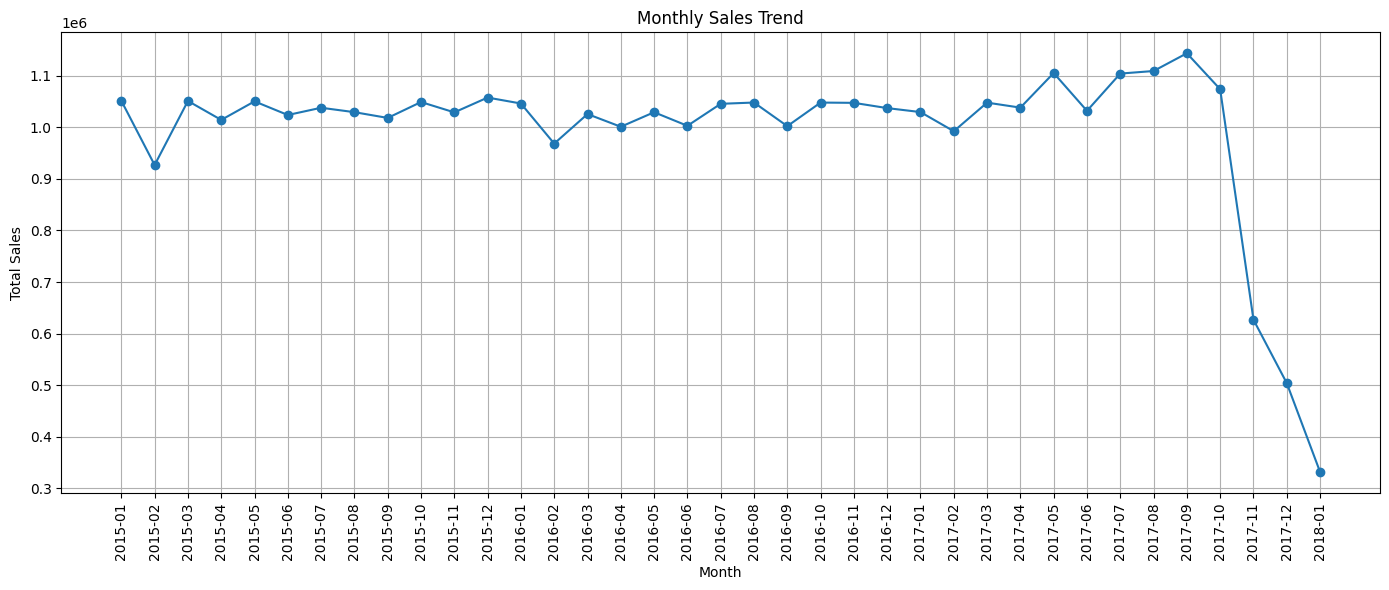

In [79]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)

plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend')

plt.xticks(rotation=90)
plt.grid(True)

plt.tight_layout()
plt.show()

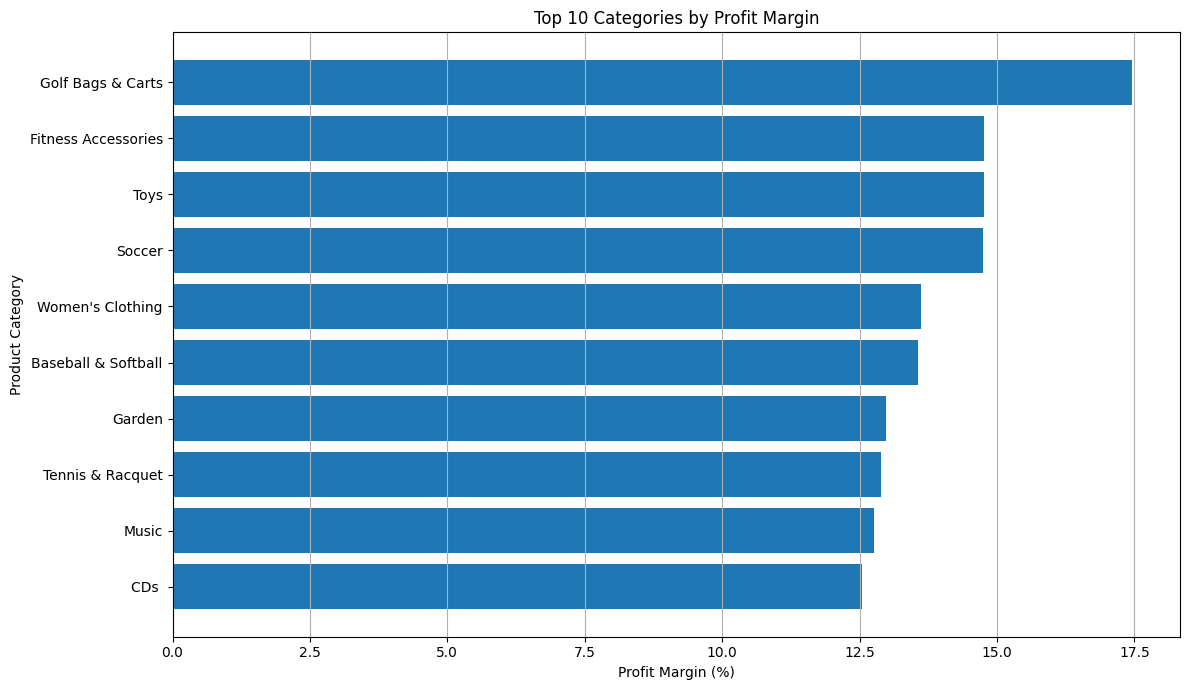

In [87]:
top_margin_categories = (
    category_financials
    .sort_values('Profit_Margin', ascending=False)
    .head(10)
    .sort_values('Profit_Margin')
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_margin_categories.index,
    top_margin_categories['Profit_Margin']
)

plt.xlabel('Profit Margin (%)')
plt.ylabel('Product Category')
plt.title('Top 10 Categories by Profit Margin')

plt.grid(axis='x')
plt.tight_layout()

plt.show()

In [88]:
 project_summary = {
    'Total Records': len(df),
    'Total Sales': df['Sales'].sum(),
    'Total Profit': df['Order Profit Per Order'].sum(),
    'Late Delivery Rate': (
        df['Delivery Status'] == 'Late delivery'
    ).mean() * 100,
    'On-Time Shipping Rate': (
        df['Delivery Status'] == 'Shipping on time'
    ).mean() * 100
}

summary_df = pd.DataFrame(
    project_summary.items(),
    columns=['Metric', 'Value']
)

summary_df

,Metric,Value
0,Total Records,1.805190e+05
1,Total Sales,3.678474e+07
2,Total Profit,3.966903e+06
3,Average Sales per Record,2.037721e+02
4,Average Profit per Record,2.197499e+01
5,Late Delivery Rate,5.482913e+01
6,On-Time Shipping Rate,1.783524e+01
